<a href="https://colab.research.google.com/github/JCMR-Andrade/Main/blob/main/Script%20CLUSTERS%20V_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="markdown-google-sans">
  <h1>Conheça o Colab</h1>
</div>

<div class="markdown-google-sans">
  <h2>&#40;Novidade&#41; Teste a API Gemini</h2>
  <ul>
  <li><a href="https://makersuite.google.com/app/apikey">Generate a Gemini API key</a></li>
  <li><a href="https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Talk_to_Gemini_with_Google%27s_Speech_to_Text_API.ipynb?utm_medium=link&utm_campaign=gemini">Talk to Gemini with the Speech-to-Text API</a></li>
  <li><a href="https://colab.research.google.com/github/google/generative-ai-docs/blob/main/site/en/tutorials/quickstart_colab.ipynb?utm_medium=link&utm_campaign=gemini">Gemini API: Quickstart with Python</a></li>
  <li><a href="https://colab.research.google.com/notebooks/snippets/gemini.ipynb?utm_medium=link&utm_campaign=gemini">Gemini API code sample</a></li>
  <li><a href="https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Learning_with_Gemini_and_ChatGPT.ipynb?utm_medium=link&utm_campaign=gemini">Compare Gemini with ChatGPT</a></li>  
  <li><a href="https://colab.google/notebooks/?utm_medium=link&utm_campaign=gemini">More notebooks</a></li>
  </ul>
</div>


In [1]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.9/198.9 kB 2.7 MB/s eta 0:00:00


In [72]:
#%% Importando os pacotes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
import scipy.stats as stats
from scipy.stats import zscore
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
import pingouin as pg
import plotly.express as px
import plotly.io as pio

In [73]:
dados = pd.read_excel('Planilha_Rex_Jun_Teste.xlsx')
dados

,KPIs,2023-01-01 00:00:00,2023-02-01 00:00:00,2023-03-01 00:00:00,2023-04-01 00:00:00,2023-05-01 00:00:00,2023-06-01 00:00:00,2023-07-01 00:00:00,2023-08-01 00:00:00,2023-09-01 00:00:00,2023-10-01 00:00:00,2023-11-01 00:00:00,2023-12-01 00:00:00,2024-01-01 00:00:00,2024-02-01 00:00:00,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00
0,TABACARIA ESPECIAL,5188.49,5289.00,5097.99,5639.00,7202.00,632.50,546.00,8547.97,8351.00,7830.00,5753.75,7404.00,7903.00,7529.00,5097.99,5639.00,8662.00,9116.50
1,TABACARIA ORDINÁRIA,28554.50,27469.00,31882.50,32068.00,33192.75,38679.98,40724.48,35109.75,34190.75,34790.00,32031.00,36133.00,34836.00,33157.00,31882.50,32068.00,33160.00,33911.75
2,ALCOOLICO,7082.95,6632.10,7278.92,8574.08,7861.67,7598.04,8218.85,8097.40,10434.74,10186.47,11028.09,14193.90,10812.01,10677.07,7278.92,8574.08,12823.11,12025.63
3,NÃO ALCOOLICOS,14048.67,12482.60,15992.32,15009.38,9810.00,9644.59,10931.04,12871.26,14309.54,16331.20,16724.26,21651.98,15432.52,13925.43,15992.32,15009.38,14742.88,13286.53
4,FOOD SERVICE,22034.62,21098.07,25234.44,25880.28,27733.72,28530.51,32671.03,33804.58,33233.30,33278.78,33747.50,31713.30,33511.03,32754.43,25234.44,25880.28,41894.71,38555.75
5,BOMBONIERE,3627.90,4777.93,5429.96,4896.63,2381.61,5680.07,5320.90,5614.16,4631.24,4770.66,4678.51,5126.77,4558.05,4797.52,5429.96,4896.63,6091.35,5200.22
6,SORVETES,1167.50,1009.50,1282.00,1088.50,1248.00,1057.00,1015.50,1145.00,1764.50,1774.51,1566.50,1899.00,1424.90,1899.30,1282.00,1088.50,1429.60,1061.80
7,SNACKS E BISCOITOS APERITIVOS,1075.12,1173.61,1982.07,1300.26,1690.65,1782.25,1828.50,1459.46,1835.74,2120.00,2147.81,2312.16,1945.71,1629.69,1982.07,1300.26,2198.90,2194.30
8,OUTRAS CATEGORIAS,3217.60,3677.45,3464.53,2881.76,11387.52,8216.44,3970.08,3467.47,3543.87,3549.18,4434.50,5738.29,3540.23,3910.01,3464.53,2881.76,4389.66,3933.26


In [74]:
dados_t = dados.T
dados_t

,0,1,2,3,4,5,6,7,8
KPIs,TABACARIA ESPECIAL,TABACARIA ORDINÁRIA,ALCOOLICO,NÃO ALCOOLICOS,FOOD SERVICE,BOMBONIERE,SORVETES,SNACKS E BISCOITOS APERITIVOS,OUTRAS CATEGORIAS
2023-01-01 00:00:00,5188.49,28554.5,7082.95,14048.67,22034.62,3627.9,1167.5,1075.12,3217.6
2023-02-01 00:00:00,5289.0,27469.0,6632.1,12482.6,21098.07,4777.93,1009.5,1173.61,3677.45
2023-03-01 00:00:00,5097.99,31882.5,7278.92,15992.32,25234.44,5429.96,1282.0,1982.07,3464.53
2023-04-01 00:00:00,5639.0,32068.0,8574.08,15009.38,25880.28,4896.63,1088.5,1300.26,2881.76
2023-05-01 00:00:00,7202.0,33192.75,7861.67,9810.0,27733.72,2381.61,1248.0,1690.65,11387.52
2023-06-01 00:00:00,632.5,38679.98,7598.04,9644.59,28530.51,5680.07,1057.0,1782.25,8216.44
2023-07-01 00:00:00,546.0,40724.48,8218.85,10931.04,32671.03,5320.9,1015.5,1828.5,3970.08
2023-08-01 00:00:00,8547.97,35109.75,8097.4,12871.26,33804.58,5614.16,1145.0,1459.46,3467.47
2023-09-01 00:00:00,8351.0,34190.75,10434.74,14309.54,33233.3,4631.24,1764.5,1835.74,3543.87


In [76]:
dados.columns = ['KPIs',
                 'Janeiro_23',
                 'Fevereiro_23',
                 'Março_23',
                 'Abril_23',
                 'Maio_23',
                 'Junho_23',
                 'Julho_23',
                 'Agosto_23',
                 'Setembro_23',
                 'Outubro_23',
                 'Novembro_23',
                 'Dezembro_23',
                 'Janeiro_24',
                 'Fevereiro_24',
                 'Março_24',
                 'Abril_24',
                 'Maio_24',
                 'Junho_24']


In [77]:
#%% Gráfico 3D das observações

fig = px.scatter_3d(dados,
                    x='Janeiro_23',
                    y='Junho_23',
                    z='Dezembro_23',
                    text=dados.index)
fig.show()

In [82]:
# Aplicando o procedimento de ZScore

dados_pad = dados.apply(zscore, ddof=1)
dados_pad

,Janeiro_23,Fevereiro_23,Março_23,Abril_23,Maio_23,Junho_23,Julho_23,Agosto_23,Setembro_23,Outubro_23,Novembro_23,Dezembro_23,Janeiro_24,Fevereiro_24,Março_24,Abril_24,Maio_24,Junho_24
0,-0.442341,-0.430969,-0.520798,-0.460423,-0.365009,-0.803573,-0.757637,-0.280801,-0.324157,-0.380183,-0.535959,-0.511943,-0.366380,-0.380983,-0.520798,-0.460423,-0.369483,-0.301330
1,1.924567,1.958205,1.904569,1.890381,1.900362,2.058889,1.973496,1.741999,1.705837,1.708722,1.565079,1.711378,1.706841,1.685753,1.904569,1.890381,1.347933,1.504496
2,-0.250438,-0.286293,-0.323312,-0.199354,-0.307511,-0.279528,-0.236075,-0.315114,-0.160456,-0.197600,-0.114241,0.013523,-0.142453,-0.127111,-0.323312,-0.199354,-0.077771,-0.089459
3,0.455169,0.343908,0.465696,0.373053,-0.137694,-0.125558,-0.051714,0.048437,0.143951,0.278503,0.341205,0.590700,0.213220,0.134849,0.465696,0.373053,0.056813,0.002371
4,1.264122,1.271944,1.302580,1.339997,1.424549,1.295305,1.426062,1.642605,1.630619,1.591630,1.702324,1.369340,1.604849,1.653288,1.302580,1.339997,1.960274,1.842716
5,-0.600424,-0.486020,-0.490738,-0.526455,-0.785157,-0.423824,-0.433063,-0.504225,-0.616385,-0.617226,-0.621931,-0.688177,-0.623864,-0.601259,-0.490738,-0.526455,-0.549696,-0.586551
6,-0.849655,-0.891946,-0.866340,-0.865180,-0.883963,-0.771636,-0.725723,-0.844571,-0.841598,-0.849373,-0.870757,-0.937972,-0.865045,-0.834982,-0.866340,-0.865180,-0.876505,-0.887950
7,-0.859013,-0.874268,-0.802948,-0.846345,-0.845381,-0.717072,-0.670459,-0.820624,-0.836002,-0.822604,-0.824277,-0.905998,-0.824954,-0.856724,-0.802948,-0.846345,-0.822574,-0.805470
8,-0.641986,-0.604561,-0.668710,-0.705674,-0.000196,-0.233003,-0.524886,-0.667705,-0.701810,-0.711868,-0.641442,-0.640851,-0.702213,-0.672831,-0.668710,-0.705674,-0.668992,-0.678823


In [83]:
# Visualizando o resultado do procedimento na média e desvio padrão
print(round(dados_pad.mean(), 2))
print(round(dados_pad.std(), 2))

Janeiro_23     -0.0
Fevereiro_23    0.0
Março_23       -0.0
Abril_23        0.0
Maio_23         0.0
Junho_23       -0.0
Julho_23       -0.0
Agosto_23      -0.0
Setembro_23     0.0
Outubro_23      0.0
Novembro_23    -0.0
Dezembro_23    -0.0
Janeiro_24      0.0
Fevereiro_24   -0.0
Março_24       -0.0
Abril_24        0.0
Maio_24         0.0
Junho_24        0.0
dtype: float64
Janeiro_23      1.0
Fevereiro_23    1.0
Março_23        1.0
Abril_23        1.0
Maio_23         1.0
Junho_23        1.0
Julho_23        1.0
Agosto_23       1.0
Setembro_23     1.0
Outubro_23      1.0
Novembro_23     1.0
Dezembro_23     1.0
Janeiro_24      1.0
Fevereiro_24    1.0
Março_24        1.0
Abril_24        1.0
Maio_24         1.0
Junho_24        1.0
dtype: float64


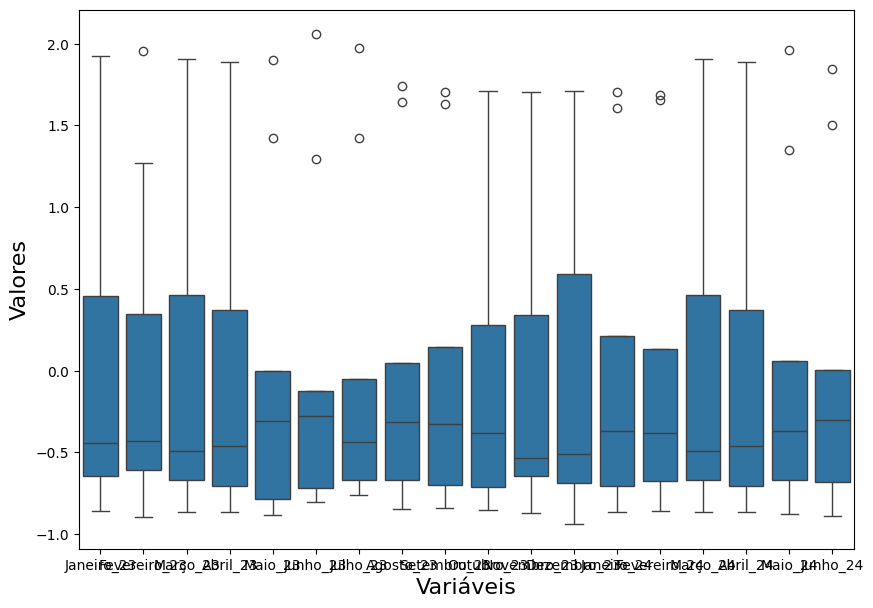

In [84]:
#%% Boxplot com as três variáveis originais

plt.figure(figsize=(10,7))
sns.boxplot(x='variable', y='value', data=pd.melt(dados_pad))
plt.ylabel('Valores', fontsize=16)
plt.xlabel('Variáveis', fontsize=16)
plt.show()

In [105]:
dist_eucl = pdist(dados_pad, metric='euclidean')
dist_eucl = pd.DataFrame(dist_eucl)
dist_eucl.sort_values(0, inplace=True)
dist_eucl

,0
33,0.181554
32,0.940202
4,0.960850
31,1.127027
35,1.187942
1,1.257729
7,1.267713
30,1.268898
34,1.310123
17,1.678226


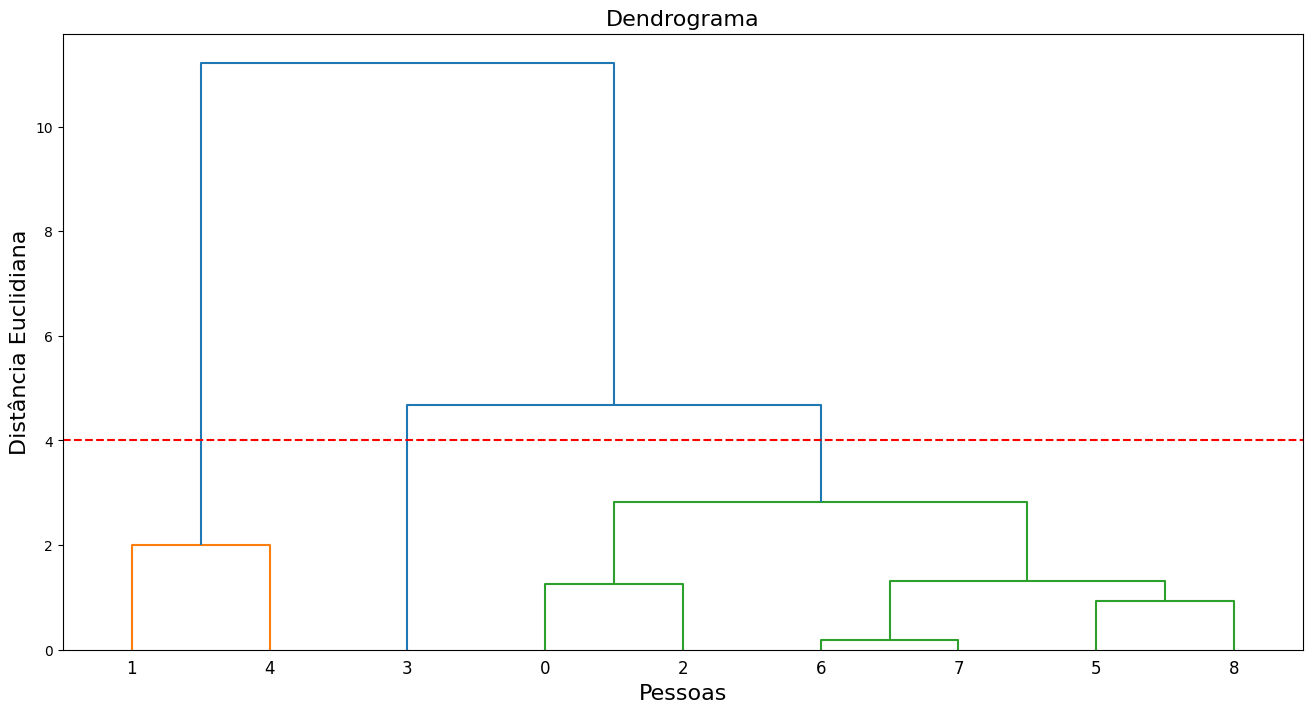

In [107]:
plt.figure(figsize=(16,8))
dend_sing = sch.linkage(dados_pad, method = 'complete', metric = 'euclidean')
dendrogram_s = sch.dendrogram(dend_sing, color_threshold = 4.5, labels = list(dados.index))
plt.title('Dendrograma', fontsize=16)
plt.xlabel('Pessoas', fontsize=16)
plt.ylabel('Distância Euclidiana', fontsize=16)
plt.axhline(y = 4, color = 'red', linestyle = '--')
plt.show()

In [117]:
# A medida de distância e o método de encadeamento são mantidos

cluster_comp = AgglomerativeClustering(n_clusters = 4, metric = 'euclidean', linkage = 'complete')
indica_cluster_comp = cluster_comp.fit_predict(dados)
dados['cluster_complete'] = indica_cluster_comp
dados['cluster_complete'] = dados['cluster_complete'].astype('category')



In [118]:
# Coeficientes do esquema hierárquico de aglomeração (complete)
coef_complete = [y[1] for y in dendrogram_s['dcoord']]
print(coef_complete)


[2.0031966300383157, 1.2577286931779508, 0.18155448383263556, 0.9402024868551114, 1.3101226509121782, 2.8217082591664244, 4.678370888222949, 11.21287246576493]


In [119]:
#%% Cluster Não Hierárquico K-means

# Considerando que identificamos 3 possíveis clusters na análise hierárquica

kmeans = KMeans(n_clusters=4, init='random', random_state=100).fit(dados)

# Gerando a variável para identificarmos os clusters gerados

kmeans_clusters = kmeans.labels_
dados['cluster_kmeans'] = kmeans_clusters
dados['cluster_kmeans'] = dados['cluster_kmeans'].astype('category')
dados.columns

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



Index(['Janeiro_23', 'Fevereiro_23', 'Março_23', 'Abril_23', 'Maio_23',
       'Junho_23', 'Julho_23', 'Agosto_23', 'Setembro_23', 'Outubro_23',
       'Novembro_23', 'Dezembro_23', 'Janeiro_24', 'Fevereiro_24', 'Março_24',
       'Abril_24', 'Maio_24', 'Junho_24', 'cluster_complete',
       'cluster_kmeans'],
      dtype='object')

In [120]:
dados_press = dados.reset_index()
d = dados_press.T
d.columns = ['TABACARIA ESPECIAL',
             'TABACARIA ORDINÁRIA',
             'ALCOOLICO',
             'NÃO ALCOOLICOS',
             'FOOD SERVICE',
             'BOMBONIERE',
             'SORVETES',
             'SNACKS E BISCOITOS APERITIVOS',
             'OUTRAS CATEGORIAS']
d2 = d.T
d2.drop(columns='index', inplace=True)
d2 = d2.to_excel('Planilha_Rex_Jun_Teste_Clusters.xlsx')

In [122]:
#%% Identificando as coordenadas centroides dos clusters finais

cent_finais = pd.DataFrame(kmeans.cluster_centers_)
cent_finais.columns = dados.columns
cent_finais.index.name = 'cluster'
cent_finais

,Janeiro_23,Fevereiro_23,Março_23,Abril_23,Maio_23,Junho_23,Julho_23,Agosto_23,Setembro_23,Outubro_23,Novembro_23,Dezembro_23,Janeiro_24,Fevereiro_24,Março_24,Abril_24,Maio_24,Junho_24,cluster_complete,cluster_kmeans
cluster,,,,,,,,,,,,,,,,,,,,
0,2272.03,2659.6225,3039.640,2541.7875,4176.945,4183.940,3033.745,2921.5225,2943.8375,3053.5875,3206.83,3769.055,2867.2225,3059.130,3039.640,2541.7875,3527.3775,3097.395,3.0,1.0
1,25294.56,24283.5350,28558.470,28974.1400,30463.235,33605.245,36697.755,34457.1650,33712.0250,34034.3900,32889.25,33923.150,34173.5150,32955.715,28558.470,28974.1400,37527.3550,36233.750,0.0,0.0
2,14048.67,12482.6000,15992.320,15009.3800,9810.000,9644.590,10931.040,12871.2600,14309.5400,16331.2000,16724.26,21651.980,15432.5200,13925.430,15992.320,15009.3800,14742.8800,13286.530,2.0,2.0
3,6135.72,5960.5500,6188.455,7106.5400,7531.835,4115.270,4382.425,8322.6850,9392.8700,9008.2350,8390.92,10798.950,9357.5050,9103.035,6188.455,7106.5400,10742.5550,10571.065,1.0,1.5


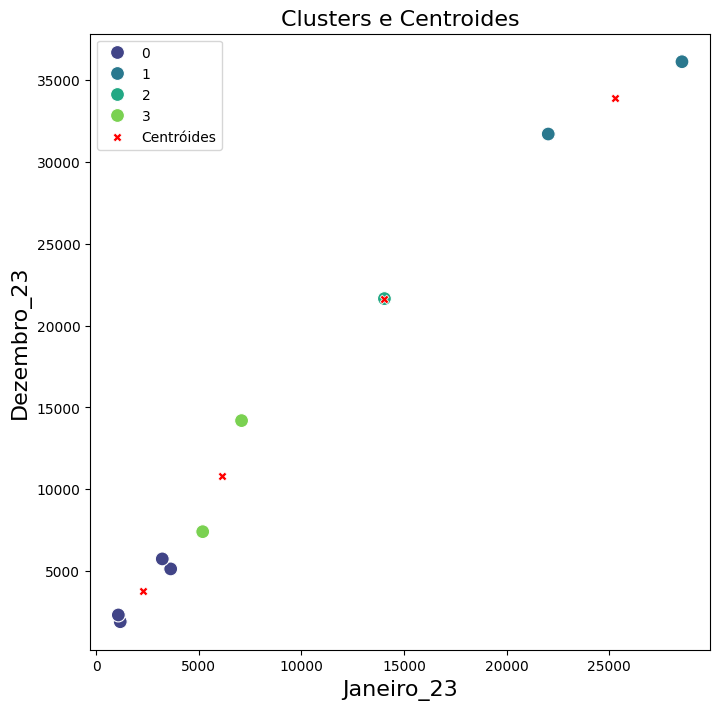

In [123]:
#%% Plotando as observações e seus centroides dos clusters

plt.figure(figsize=(8,8))
sns.scatterplot(data=dados, x='Janeiro_23', y='Dezembro_23', hue='cluster_kmeans', palette='viridis', s=100)
sns.scatterplot(data=cent_finais, x='Janeiro_23', y='Dezembro_23', c = 'red', label = 'Centróides', marker="X", s = 40)
plt.title('Clusters e Centroides', fontsize=16)
plt.xlabel('Janeiro_23', fontsize=16)
plt.ylabel('Dezembro_23', fontsize=16)
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



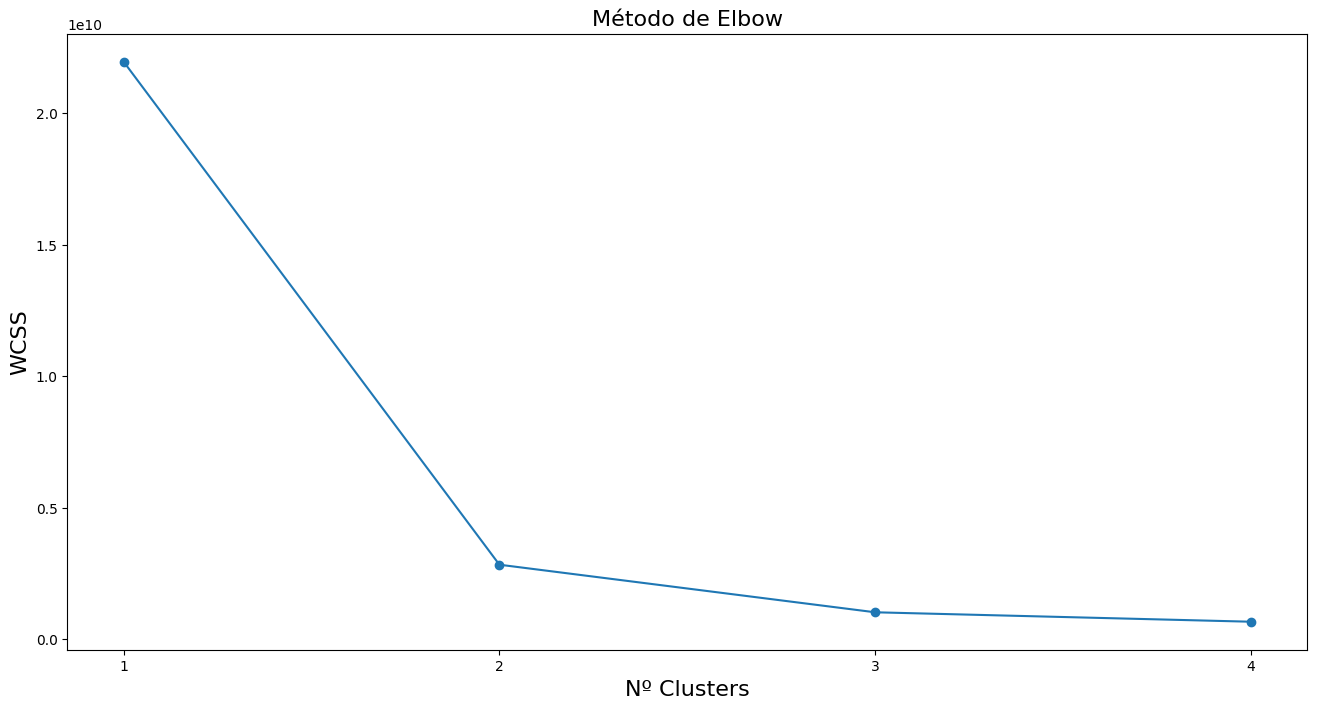

In [124]:
#%% Identificação da quantidade de clusters

# Método Elbow para identificação do nº de clusters
## Elaborado com base na "WCSS": distância de cada observação para o centroide de seu cluster
## Quanto mais próximos entre si e do centroide, menores as distâncias internas
## Normalmente, busca-se o "cotovelo", ou seja, o ponto onde a curva "dobra"

elbow = []
K = range(1,5) # ponto de parada pode ser parametrizado manualmente
for k in K:
    kmeanElbow = KMeans(n_clusters=k, init='random', random_state=100).fit(dados)
    elbow.append(kmeanElbow.inertia_)

plt.figure(figsize=(16,8))
plt.plot(K, elbow, marker='o')
plt.xlabel('Nº Clusters', fontsize=16)
plt.xticks(range(1,5))
plt.ylabel('WCSS', fontsize=16)
plt.title('Método de Elbow', fontsize=16)
plt.show()


In [125]:
# Matemática
pg.anova(dv='Janeiro_23',
         between='cluster_kmeans',
         data=dados,
         detailed=True).T

# Física
pg.anova(dv='Julho_23',
         between='cluster_kmeans',
         data=dados,
         detailed=True).T

# Química
pg.anova(dv='Dezembro_23',
         between='cluster_kmeans',
         data=dados,
         detailed=True).T

,0,1
Source,cluster_kmeans,Within
SS,1291595691.924722,44159170.3005
DF,3,5
MS,430531897.308241,8831834.0601
F,48.747734,NaN
p-unc,0.0004,NaN
np2,0.966941,NaN


In [126]:
#%% Gráfico 3D dos clusters

fig = px.scatter_3d(dados,
                    x='Janeiro_23',
                    y='Julho_23',
                    z='Dezembro_23',
                    color='cluster_kmeans',
                    text=dados.index)
fig.show()